In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from datasets import load_dataset
import json
model_name = "facebook/nllb-200-distilled-600M"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
model = model.half().to("cuda")  # FP16
model.eval()

import pandas as pd
mapping = pd.read_csv('fasttext_nllb_mapping_98.csv')
mapping = mapping[(mapping.Duplicate_Flag == False) & (mapping.Missing_Flag == False)][['fasttext_code','NLLB_Code']]

mapping_dict = dict(zip(mapping['fasttext_code'], mapping['NLLB_Code']))
len(mapping_dict)
lang_code = mapping_dict

def translate_batch(texts, target_lang):
    forced_bos_token_id = tokenizer.convert_tokens_to_ids(lang_code[target_lang])
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to("cuda")
    with torch.no_grad():
        translated_tokens = model.generate(
            **inputs, forced_bos_token_id=forced_bos_token_id, max_length=128
        )
    translations = tokenizer.batch_decode(translated_tokens, skip_special_tokens=True)
    return translations

def translate_function(dataset,target_langs,columns_to_translate):
    with open(output_file, "w", encoding="utf-8") as f:
        batch_rows = []
        
        for item in dataset:
            row = {col: item[col] for col in columns_to_translate if col in item}
            batch_rows.append(row)
            
            if len(batch_rows) == batch_size:
                # Translate each column for all target languages
                for lang in target_langs:
                    for col in columns_to_translate:
                        if col in row:
                            texts = [r[col] for r in batch_rows]
                            translated = translate_batch(texts, lang)
                            for i, r in enumerate(batch_rows):
                                r[f"{col}_{lang}"] = translated[i]
                
                # Write batch to JSONL
                for r in batch_rows:
                    f.write(json.dumps(r, ensure_ascii=False) + "\n")
                
                batch_rows = []
    
        # Translate remaining rows
        if batch_rows:
            for lang in target_langs:
                for col in columns_to_translate:
                    if col in row:
                        texts = [r[col] for r in batch_rows]
                        translated = translate_batch(texts, lang)
                        for i, r in enumerate(batch_rows):
                            r[f"{col}_{lang}"] = translated[i]
            for r in batch_rows:
                f.write(json.dumps(r, ensure_ascii=False) + "\n")
    
    print(f"Multi-column multi-language translation completed! Saved to {output_file}")
# batch_size = 64
# output_file = "mgsm_multicolumn_multilang.jsonl"
# columns_to_translate = ["question"] 
# target_langs = list(mapping_dict)
# dataset = load_dataset("juletxara/mgsm", "en",split="test")
# translate_function(dataset,target_langs,columns_to_translate)

In [2]:
from datasets import load_dataset
dataset = load_dataset("json", data_files="mgsm_multicolumn_multilang_final.jsonl", split="train")

batch_size = 64
output_file = "mgsm_translate_back_nllb.jsonl"
columns_to_translate = list(dataset.features.keys())[1:]
target_langs = ['en']

translate_function(dataset,target_langs,columns_to_translate)

Multi-column multi-language translation completed! Saved to mgsm_translate_back_nllb.jsonl


In [3]:
from datasets import load_dataset
dataset = load_dataset("json", data_files="msvamp_multicolumn_multilang_final.jsonl", split="train")

batch_size = 64
output_file = "msvamp_translate_back_nllb.jsonl"
columns_to_translate = list(dataset.features.keys())[1:]
target_langs = ['en']

translate_function(dataset,target_langs,columns_to_translate)

Multi-column multi-language translation completed! Saved to msvamp_translate_back_nllb.jsonl


# STATS Translation

In [ ]:
file = "mgsm_translate_back_nllb.jsonl"

In [3]:
sample_langs = {
    "bn": "Bengali", "bo": "Tibetan", "ug": "Uyghur", "kk": "Kazakh",
    "mn": "Mongolian", "km": "Khmer", "mr": "Marathi", "hi": "Hindi",
    "ko": "Korean", "es": "Spanish"
}
sample_langs.keys()

dict_keys(['bn', 'bo', 'ug', 'kk', 'mn', 'km', 'mr', 'hi', 'ko', 'es'])

,question_hi,question_hi_en
0,जैनेट के बत्ख प्रतिदिन 16 अंडे देते हैं। हर सु...,Janet’s ducks lay 16 eggs every day. Every mor...
1,एक रोब (robe) के निर्माण हेतु 2 बोल्ट नीले रंग...,"To make one robe, 2 bolts of blue fiber and ha..."
2,"जोश ने एक घर खरीदा, जिसकी कीमत 80,000 डॉलर थी;...","`\nJosh bought a house that cost 80,000 dollar..."
3,जेम्स ने तय किया है कि वह हफ्ते में तीन बार प्...,James has decided to do three sprints three ti...
4,"हर दिन, वेंडी अपनी मुर्गियों को तीन बार खाना द...","Each day, Wendy feeds her chickens three times..."


In [31]:
import pandas as pd
from collections import defaultdict
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from sacrebleu.metrics import TER
import nltk

# Download WordNet for METEOR
nltk.download('wordnet')

# -------------------------------
# Load original English questions
df_orig = pd.read_json("mgsm_multicolumn_multilang_final.jsonl", lines=True)

# Load back-translated English columns
df_back = pd.read_json("mgsm_translate_back_nllb.jsonl", lines=True)

# Filter only columns ending with _en
en_columns = [col for col in df_back.columns if col.endswith("_en")]
df_back = df_back[en_columns]

# -------------------------------
# Merge dataframes on index
df_merged = pd.concat([df_orig['question'], df_back], axis=1)

# -------------------------------
# Detect languages from back-translated columns
languages = [col.replace("question_", "").replace("_en", "") for col in df_back.columns]
print("Languages detected:", languages)
languages = ['bn', 'bo', 'ug', 'kk', 'km', 'mr', 'hi', 'ko', 'es'] 

# -------------------------------
# Initialize metric storage
results = defaultdict(dict)

# Initialize scorers
rouge_scorer_instance = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
ter_scorer = TER()

# -------------------------------
# Compute metrics per language
for lang in languages:
    col_name = f"question_{lang}_en"
    references_corpus = []
    hypotheses_corpus = []
    meteor_scores = []
    rougeL_scores = []
    ter_scores = []

    for _, row in df_merged.iterrows():
        ref = row["question"]       # original English
        hyp = row[col_name]         # back-translated English

        # Tokenize
        ref_tokens = ref.split()
        hyp_tokens = hyp.split()

        # BLEU
        references_corpus.append([ref_tokens])
        hypotheses_corpus.append(hyp_tokens)

        # METEOR
        meteor_scores.append(meteor_score([ref_tokens], hyp_tokens))

        # ROUGE-L
        rougeL = rouge_scorer_instance.score(ref, hyp)['rougeL'].fmeasure
        rougeL_scores.append(rougeL)

        # TER
        ter_score = ter_scorer.sentence_score(hyp, [ref]).score
        ter_scores.append(ter_score)

    # Corpus-level BLEU
    bleu_score = corpus_bleu(references_corpus, hypotheses_corpus)

    # Aggregate metrics
    results[lang]['BLEU'] = round(bleu_score, 2)
    results[lang]['METEOR'] = round(sum(meteor_scores)/len(meteor_scores), 4)
    results[lang]['ROUGE-L'] = round(sum(rougeL_scores)/len(rougeL_scores), 4)
    results[lang]['TER'] = round(sum(ter_scores)/len(ter_scores), 4)

# -------------------------------
# Print results
for lang, metrics in results.items():
    print(f"{lang}: {metrics}")


[nltk_data] Downloading package wordnet to /home/amahaj56/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Languages detected: ['hi', 'ko', 'als', 'arz', 'ast', 'azb', 'ceb', 'ckb', 'ilo', 'lmo', 'mai', 'min', 'scn', 'vec', 'war', 'yue', 'af', 'am', 'as', 'ba', 'be', 'bn', 'bo', 'bs', 'bg', 'ca', 'cs', 'cy', 'da', 'de', 'el', 'eo', 'et', 'eu', 'fi', 'gd', 'ga', 'gl', 'gn', 'gu', 'ht', 'he', 'hr', 'hu', 'hy', 'id', 'is', 'it', 'jv', 'ja', 'kn', 'ka', 'kk', 'km', 'ky', 'lo', 'li', 'lt', 'lb', 'ml', 'mr', 'mk', 'mt', 'my', 'nl', 'nn', 'oc', 'pa', 'pl', 'pt', 'ro', 'ru', 'sa', 'si', 'sk', 'sl', 'sd', 'so', 'sc', 'sr', 'su', 'sv', 'ta', 'tt', 'te', 'tg', 'tl', 'th', 'tk', 'tr', 'ug', 'uk', 'ur', 'vi', 'yo', 'sw', 'yi', 'fr', 'es', 'zh']
bn: {'BLEU': 0.25, 'METEOR': 0.4784, 'ROUGE-L': 0.5804, 'TER': 57.3218}
bo: {'BLEU': 0.08, 'METEOR': 0.2593, 'ROUGE-L': 0.3526, 'TER': 84.5211}
ug: {'BLEU': 0.09, 'METEOR': 0.2879, 'ROUGE-L': 0.379, 'TER': 77.9132}
kk: {'BLEU': 0.09, 'METEOR': 0.2739, 'ROUGE-L': 0.3822, 'TER': 77.6851}
km: {'BLEU': 0.17, 'METEOR': 0.4079, 'ROUGE-L': 0.4755, 'TER': 78.4731}
mr: {'

In [1]:
import pandas as pd
from collections import defaultdict
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from sacrebleu.metrics import TER
import nltk

# Download WordNet for METEOR
nltk.download('wordnet')

# -------------------------------
# Load original English questions
df_orig = pd.read_json("mgsm_multicolumn_multilang_final.jsonl", lines=True)

# Load back-translated English columns
df_back = pd.read_json("mgsm_translate_back_nllb.jsonl", lines=True)

# Filter only columns ending with _en
en_columns = [col for col in df_back.columns if col.endswith("_en")]
df_back = df_back[en_columns]

# -------------------------------
# Merge dataframes on index
df_merged = pd.concat([df_orig['question'], df_back], axis=1)

# -------------------------------
# Detect languages from back-translated columns
languages = [col.replace("question_", "").replace("_en", "") for col in df_back.columns]
print("Languages detected:", languages)
# languages = ['bn', 'bo', 'ug', 'kk', 'km', 'mr', 'hi', 'ko', 'es'] 

# -------------------------------
# Initialize metric storage
results = defaultdict(dict)

# Initialize scorers
rouge_scorer_instance = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
ter_scorer = TER()

# -------------------------------
# Compute metrics per language
for lang in languages:
    col_name = f"question_{lang}_en"
    references_corpus = []
    hypotheses_corpus = []
    meteor_scores = []
    rougeL_scores = []
    ter_scores = []

    for _, row in df_merged.iterrows():
        ref = row["question"]       # original English
        hyp = row[col_name]         # back-translated English

        # Tokenize
        ref_tokens = ref.split()
        hyp_tokens = hyp.split()

        # BLEU
        references_corpus.append([ref_tokens])
        hypotheses_corpus.append(hyp_tokens)

        # METEOR
        meteor_scores.append(meteor_score([ref_tokens], hyp_tokens))

        # ROUGE-L
        rougeL = rouge_scorer_instance.score(ref, hyp)['rougeL'].fmeasure
        rougeL_scores.append(rougeL)

        # TER
        ter_score = ter_scorer.sentence_score(hyp, [ref]).score
        ter_scores.append(ter_score)

    # Corpus-level BLEU
    bleu_score = corpus_bleu(references_corpus, hypotheses_corpus)

    # Aggregate metrics
    results[lang]['BLEU'] = round(bleu_score, 2)
    results[lang]['METEOR'] = round(sum(meteor_scores)/len(meteor_scores), 4)
    results[lang]['ROUGE-L'] = round(sum(rougeL_scores)/len(rougeL_scores), 4)
    results[lang]['TER'] = round(sum(ter_scores)/len(ter_scores), 4)

# -------------------------------
# Print results
for lang, metrics in results.items():
    print(f"{lang}: {metrics}")


[nltk_data] Downloading package wordnet to /home/amahaj56/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Languages detected: ['hi', 'ko', 'als', 'arz', 'ast', 'azb', 'ceb', 'ckb', 'ilo', 'lmo', 'mai', 'min', 'scn', 'vec', 'war', 'yue', 'af', 'am', 'as', 'ba', 'be', 'bn', 'bo', 'bs', 'bg', 'ca', 'cs', 'cy', 'da', 'de', 'el', 'eo', 'et', 'eu', 'fi', 'gd', 'ga', 'gl', 'gn', 'gu', 'ht', 'he', 'hr', 'hu', 'hy', 'id', 'is', 'it', 'jv', 'ja', 'kn', 'ka', 'kk', 'km', 'ky', 'lo', 'li', 'lt', 'lb', 'ml', 'mr', 'mk', 'mt', 'my', 'nl', 'nn', 'oc', 'pa', 'pl', 'pt', 'ro', 'ru', 'sa', 'si', 'sk', 'sl', 'sd', 'so', 'sc', 'sr', 'su', 'sv', 'ta', 'tt', 'te', 'tg', 'tl', 'th', 'tk', 'tr', 'ug', 'uk', 'ur', 'vi', 'yo', 'sw', 'yi', 'fr', 'es', 'zh']
hi: {'BLEU': 0.39, 'METEOR': 0.6149, 'ROUGE-L': 0.6908, 'TER': 44.8152}
ko: {'BLEU': 0.18, 'METEOR': 0.4195, 'ROUGE-L': 0.5296, 'TER': 62.4639}
als: {'BLEU': 0.11, 'METEOR': 0.28, 'ROUGE-L': 0.3764, 'TER': 77.9711}
arz: {'BLEU': 0.23, 'METEOR': 0.4565, 'ROUGE-L': 0.5314, 'TER': 60.7672}
ast: {'BLEU': 0.14, 'METEOR': 0.299, 'ROUGE-L': 0.3942, 'TER': 80.8267}
azb: 

In [2]:
avg_bleu = sum(results[lang]['BLEU'] for lang in languages) / len(languages)
avg_meteor = sum(results[lang]['METEOR'] for lang in languages) / len(languages)
avg_rouge = sum(results[lang]['ROUGE-L'] for lang in languages) / len(languages)
avg_ter = sum(results[lang]['TER'] for lang in languages) / len(languages)

print("\n===== AVERAGE METRICS ACROSS ALL LANGUAGES =====")
print(f"Average BLEU: {avg_bleu:.4f}")
print(f"Average METEOR: {avg_meteor:.4f}")
print(f"Average ROUGE-L: {avg_rouge:.4f}")
print(f"Average TER: {avg_ter:.4f}")


===== AVERAGE METRICS ACROSS ALL LANGUAGES =====
Average BLEU: 0.1405
Average METEOR: 0.3202
Average ROUGE-L: 0.4155
Average TER: 74.9228


/tmp/ipykernel_3592791/3544864830.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, x=metric, y="language", palette="viridis")


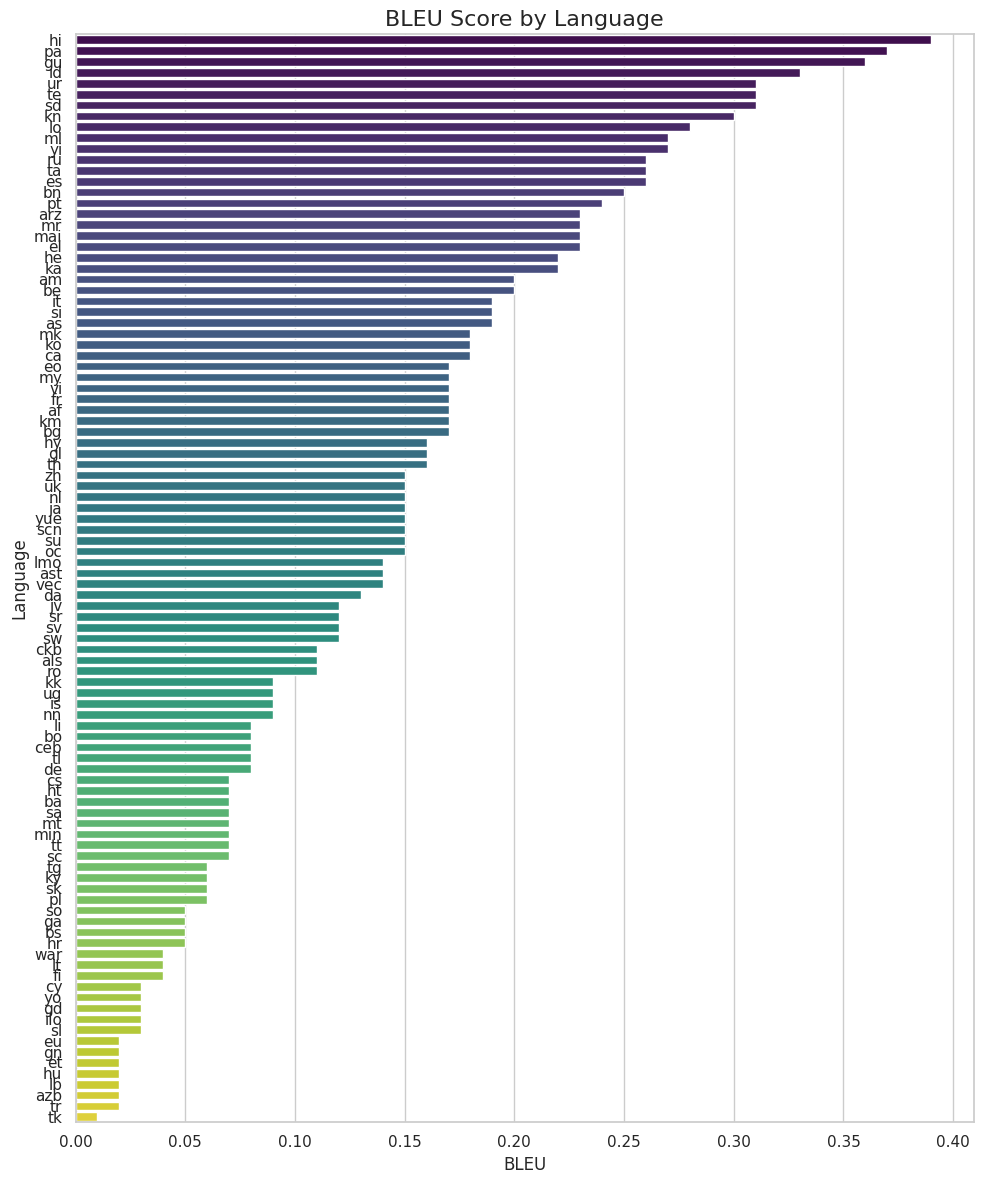

/tmp/ipykernel_3592791/3544864830.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, x=metric, y="language", palette="viridis")


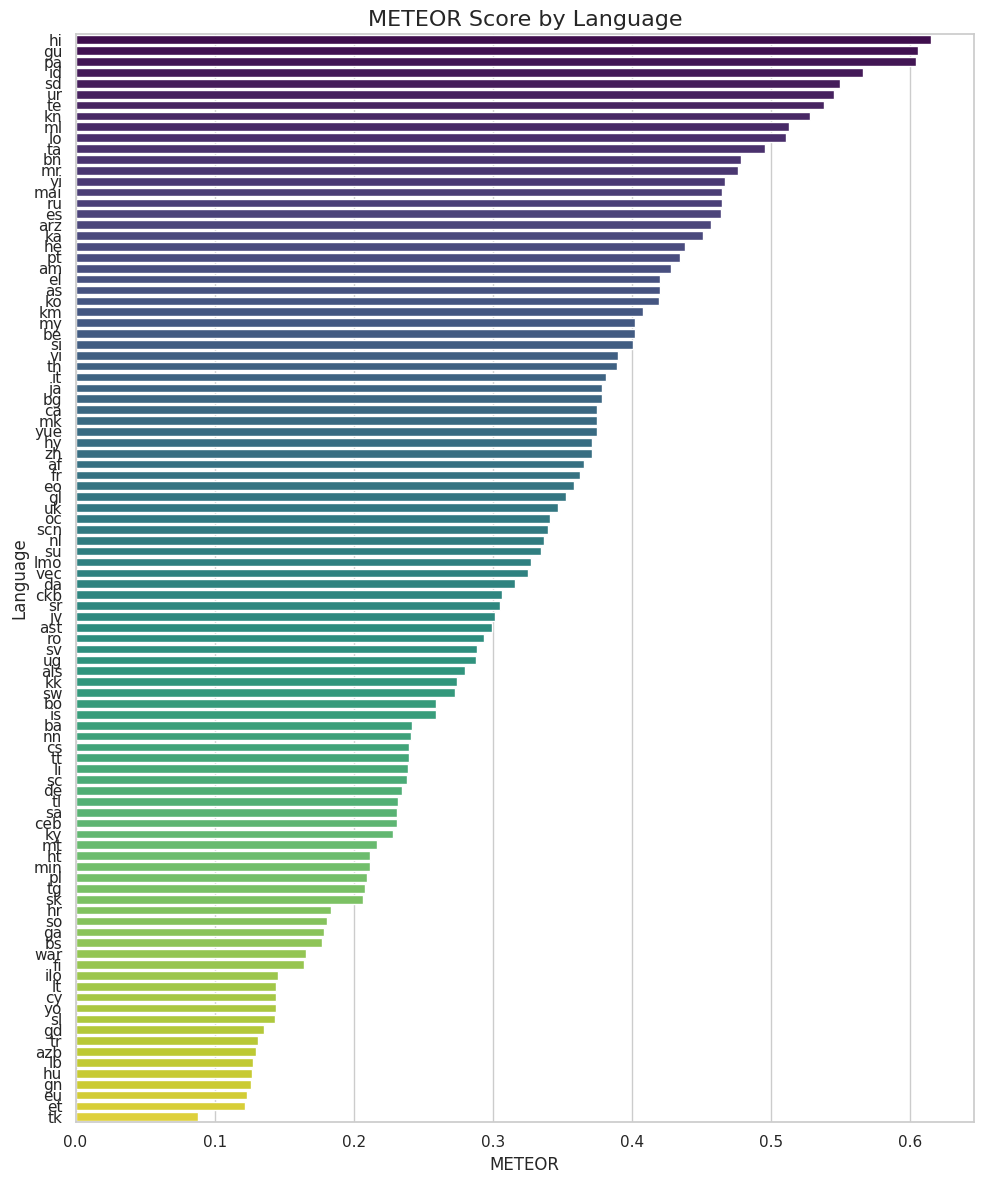

/tmp/ipykernel_3592791/3544864830.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, x=metric, y="language", palette="viridis")


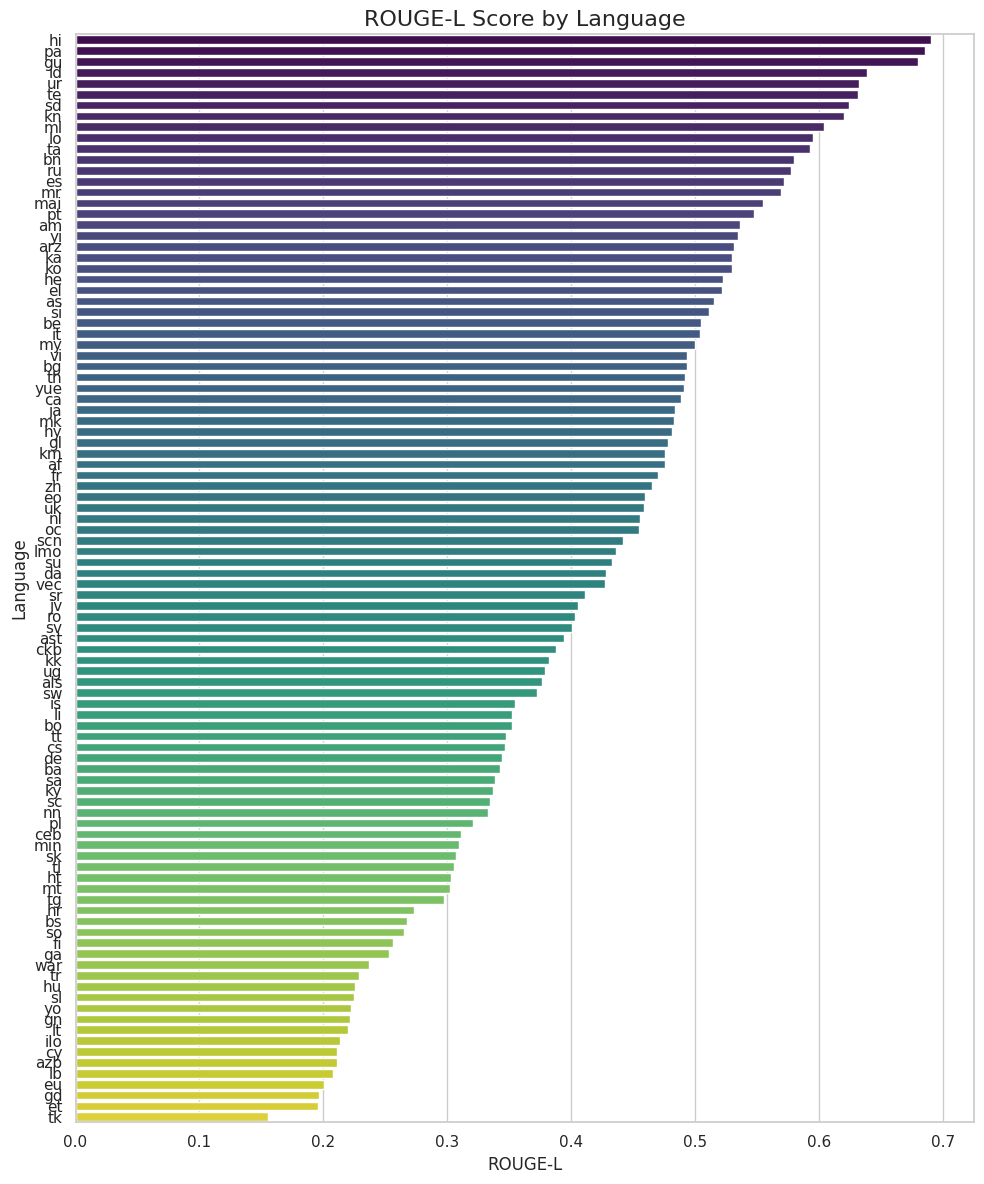

/tmp/ipykernel_3592791/3544864830.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, x=metric, y="language", palette="viridis")


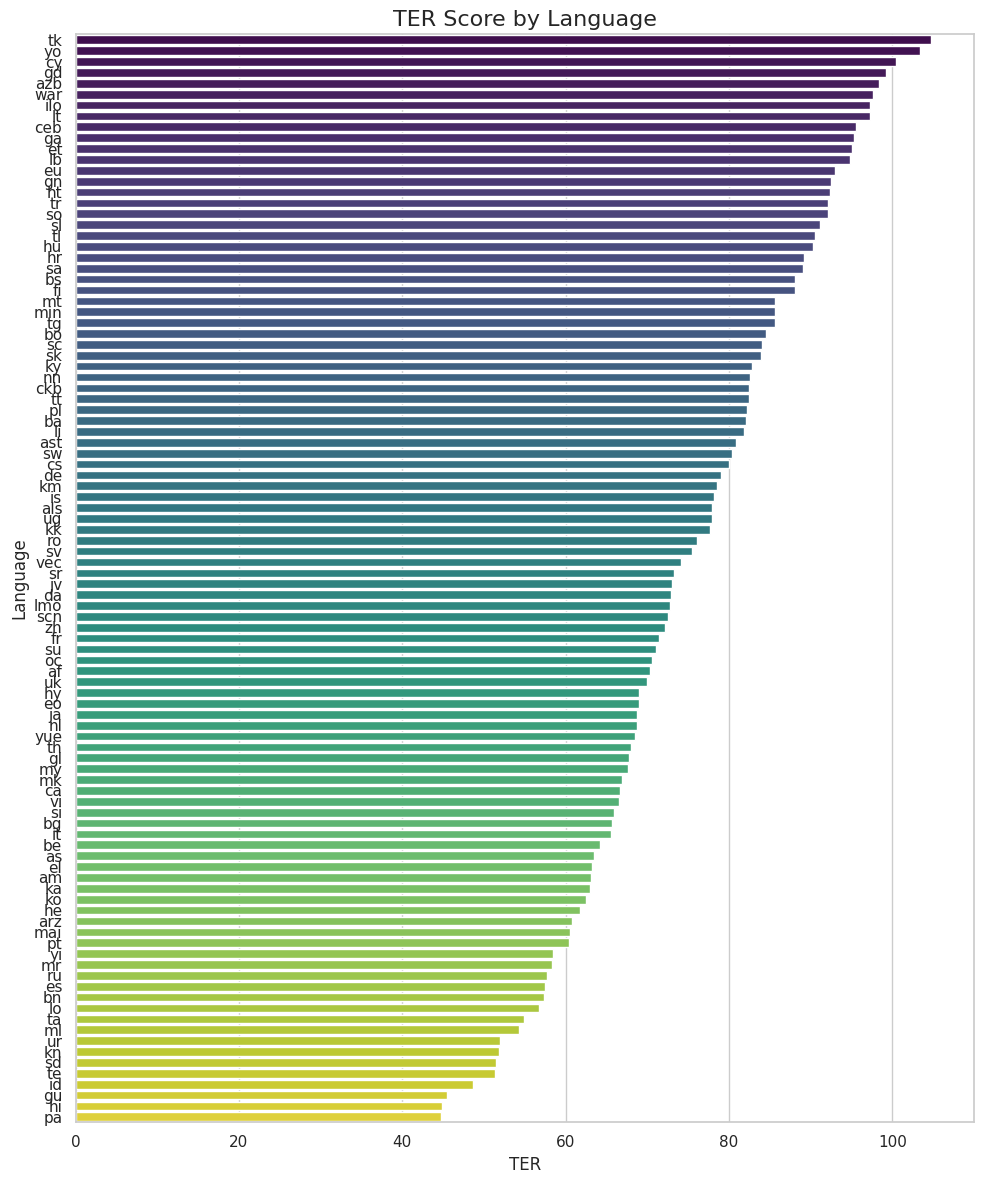

/tmp/ipykernel_3592791/3544864830.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_sorted, x=metric, y="language", size=7, palette="Set2")


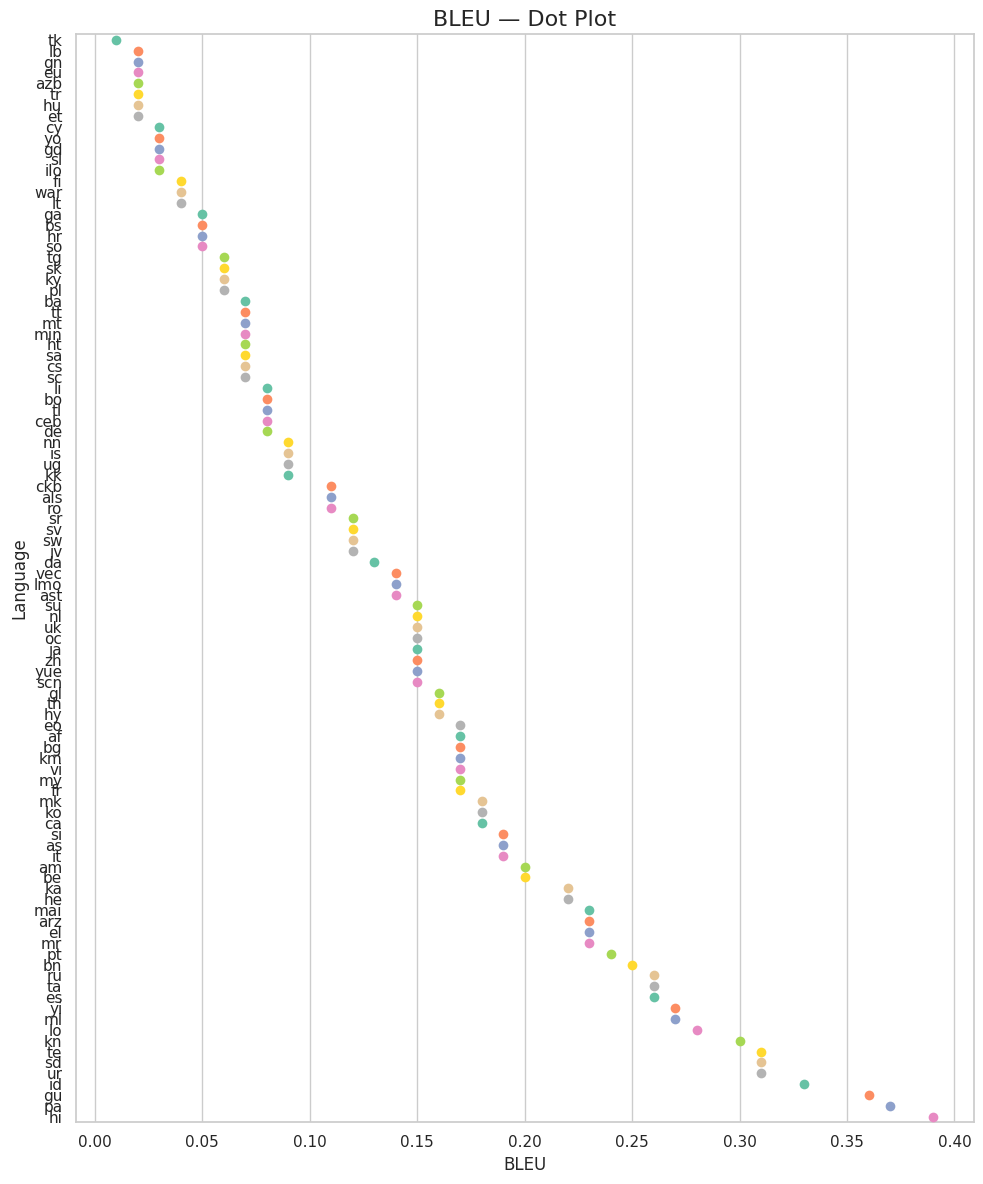

/tmp/ipykernel_3592791/3544864830.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_sorted, x=metric, y="language", size=7, palette="Set2")


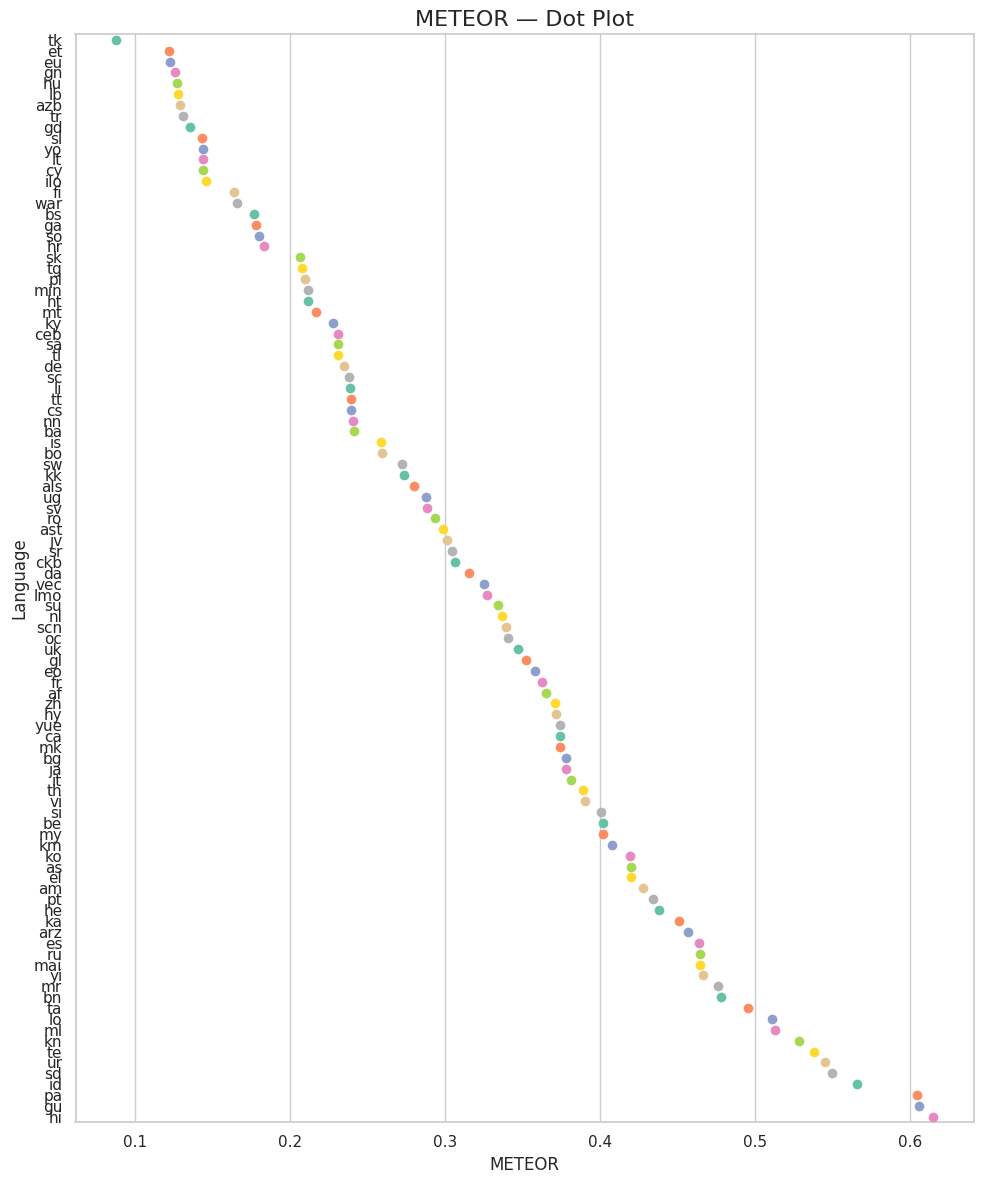

/tmp/ipykernel_3592791/3544864830.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_sorted, x=metric, y="language", size=7, palette="Set2")


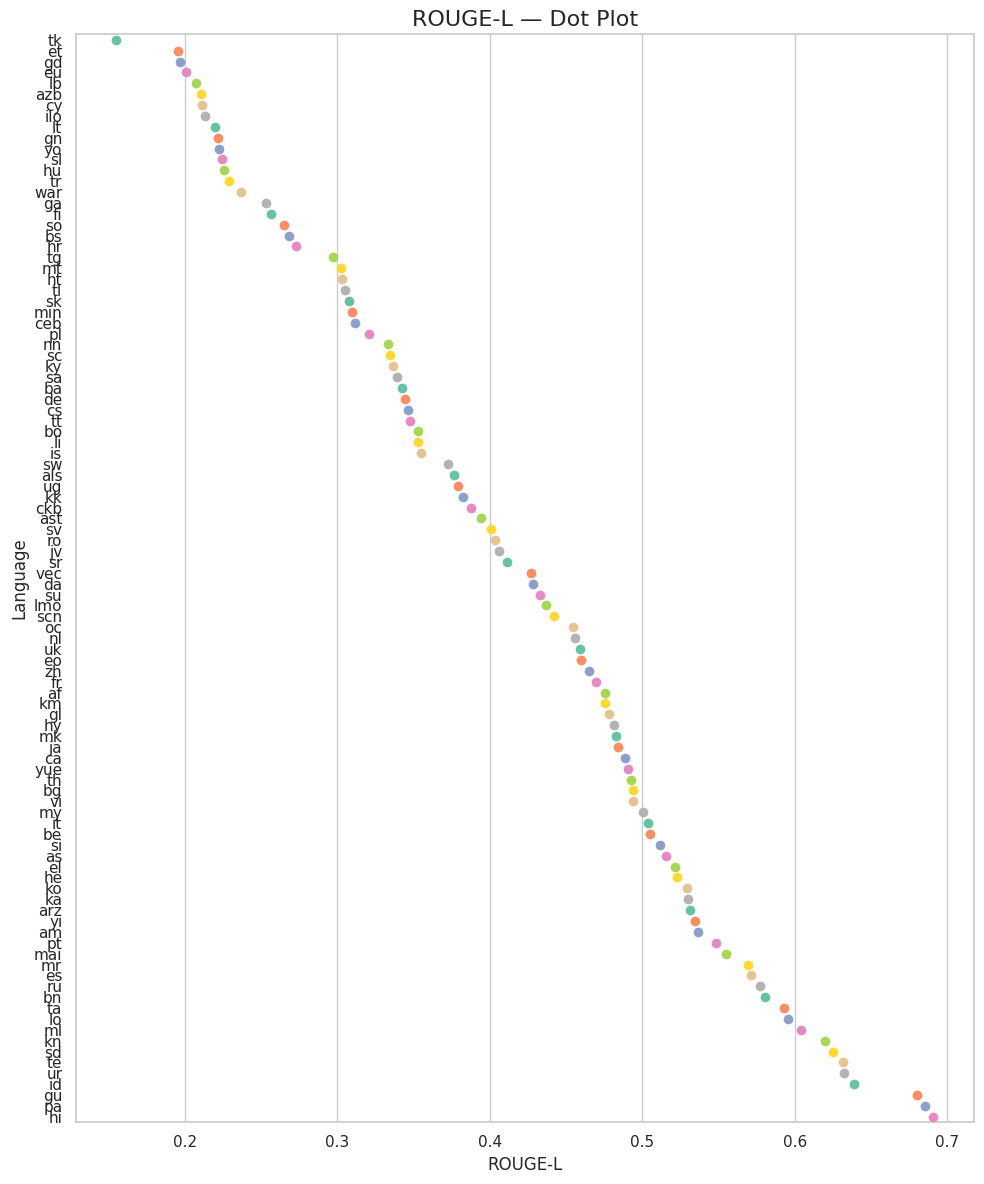

/tmp/ipykernel_3592791/3544864830.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_sorted, x=metric, y="language", size=7, palette="Set2")


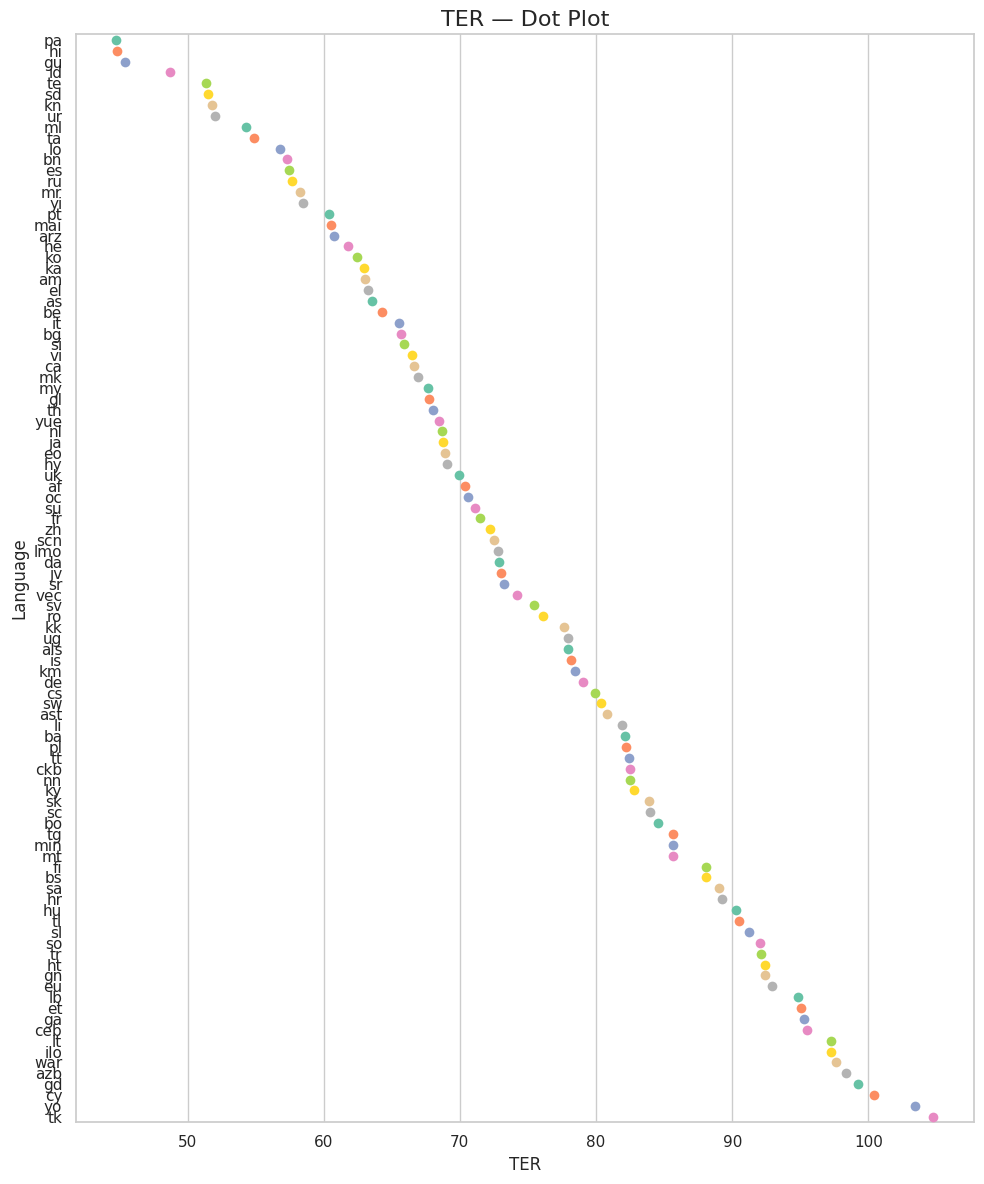

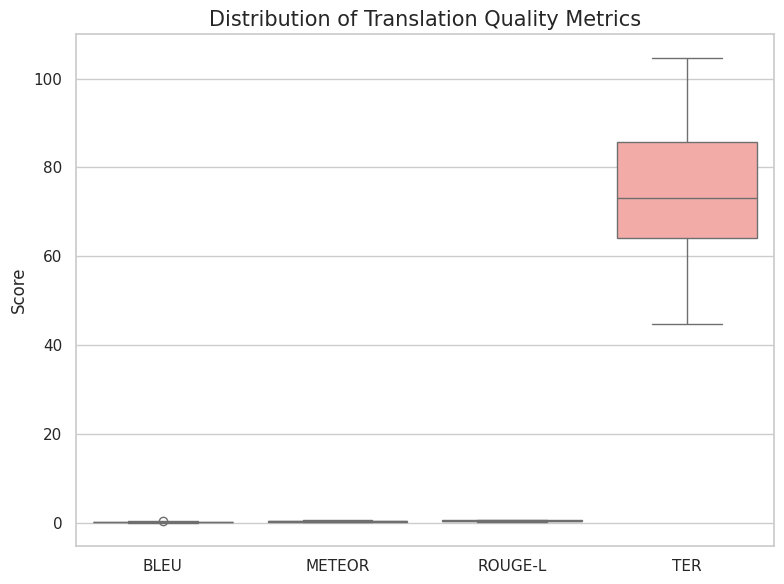

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =======================================================
# Example: df_plot must look like this:
# language | BLEU | METEOR | ROUGE-L | TER
# =======================================================

# df_plot = pd.DataFrame(results).T.reset_index().rename(columns={"index": "language"})

metrics = ["BLEU", "METEOR", "ROUGE-L", "TER"]
sns.set(style="whitegrid")

# =======================================================
# 1️⃣ Horizontal Bar Plots (best readability)
# =======================================================

for metric in metrics:
    df_sorted = df_plot.sort_values(metric, ascending=False)

    plt.figure(figsize=(10, 12))
    sns.barplot(data=df_sorted, x=metric, y="language", palette="viridis")

    plt.title(f"{metric} Score by Language", fontsize=16)
    plt.xlabel(metric)
    plt.ylabel("Language")
    plt.tight_layout()
    plt.show()

# =======================================================
# 2️⃣ Dot Plot (clean research style)
# =======================================================

for metric in metrics:
    df_sorted = df_plot.sort_values(metric)

    plt.figure(figsize=(10, 12))
    sns.stripplot(data=df_sorted, x=metric, y="language", size=7, palette="Set2")

    plt.title(f"{metric} — Dot Plot", fontsize=16)
    plt.xlabel(metric)
    plt.ylabel("Language")
    plt.tight_layout()
    plt.show()

# =======================================================
# 3️⃣ Boxplot across all metrics
#    Gives an overall distribution view
# =======================================================

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_plot[metrics], palette="pastel")
plt.title("Distribution of Translation Quality Metrics", fontsize=15)
plt.ylabel("Score")
plt.tight_layout()
plt.show()

# =======================================================
# 4️⃣ Heatmap of all metrics (best global comparison)
# ==


   Language  BLEU  METEOR  ROUGE-L      TER
0        hi  0.39  0.6149   0.6908  44.8152
1        ko  0.18  0.4195   0.5296  62.4639
2       als  0.11  0.2800   0.3764  77.9711
3       arz  0.23  0.4565   0.5314  60.7672
4       ast  0.14  0.2990   0.3942  80.8267
..      ...   ...     ...      ...      ...
95       sw  0.12  0.2726   0.3728  80.3348
96       yi  0.27  0.4667   0.5348  58.4705
97       fr  0.17  0.3628   0.4699  71.4537
98       es  0.26  0.4642   0.5716  57.4406
99       zh  0.15  0.3709   0.4650  72.2017

[100 rows x 5 columns]


In [45]:
df_orig = pd.read_json("msvamp_multicolumn_multilang_final.jsonl", lines=True)

# Load back-translated English columns
df_back = pd.read_json("msvamp_translate_back_nllb.jsonl", lines=True)

In [11]:
import pandas as pd
from collections import defaultdict
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from sacrebleu.metrics import TER
import nltk

# Download WordNet for METEOR
nltk.download('wordnet')

# -------------------------------
# Load original English questions
df_orig = pd.read_json("msvamp_multicolumn_multilang_final.jsonl", lines=True)

# Load back-translated English columns
df_back = pd.read_json("msvamp_translate_back_nllb.jsonl", lines=True)

# Filter only columns ending with _en
en_columns = [col for col in df_back.columns if col.endswith("_en")]
df_back = df_back[en_columns]

# -------------------------------
# Merge dataframes on index
df_merged = pd.concat([df_orig['m_query'], df_back], axis=1)

# -------------------------------
# Detect languages from back-translated columns
languages = [col.replace("m_query_", "").replace("_en", "") for col in df_back.columns]
print("Languages detected:", languages)
languages = ['bn', 'bo', 'ug', 'kk', 'km', 'mr', 'hi', 'ko', 'es'] 

# -------------------------------
# Initialize metric storage
results = defaultdict(dict)

# Initialize scorers
rouge_scorer_instance = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
ter_scorer = TER()

# -------------------------------
# Compute metrics per language
for lang in languages:
    col_name = f"m_query_{lang}_en"
    references_corpus = []
    hypotheses_corpus = []
    meteor_scores = []
    rougeL_scores = []
    ter_scores = []

    for _, row in df_merged.iterrows():
        ref = row["m_query"]       # original English
        hyp = row[col_name]         # back-translated English

        # Tokenize
        ref_tokens = ref.split()
        hyp_tokens = hyp.split()

        # BLEU
        references_corpus.append([ref_tokens])
        hypotheses_corpus.append(hyp_tokens)

        # METEOR
        meteor_scores.append(meteor_score([ref_tokens], hyp_tokens))

        # ROUGE-L
        rougeL = rouge_scorer_instance.score(ref, hyp)['rougeL'].fmeasure
        rougeL_scores.append(rougeL)

        # TER
        ter_score = ter_scorer.sentence_score(hyp, [ref]).score
        ter_scores.append(ter_score)

    # Corpus-level BLEU
    bleu_score = corpus_bleu(references_corpus, hypotheses_corpus)

    # Aggregate metrics
    results[lang]['BLEU'] = round(bleu_score, 2)
    results[lang]['METEOR'] = round(sum(meteor_scores)/len(meteor_scores), 4)
    results[lang]['ROUGE-L'] = round(sum(rougeL_scores)/len(rougeL_scores), 4)
    results[lang]['TER'] = round(sum(ter_scores)/len(ter_scores), 4)

# -------------------------------
# Print results
for lang, metrics in results.items():
    print(f"{lang}: {metrics}")


[nltk_data] Downloading package wordnet to /home/amahaj56/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Languages detected: ['hi', 'ko', 'als', 'arz', 'ast', 'azb', 'ceb', 'ckb', 'ilo', 'lmo', 'mai', 'min', 'scn', 'vec', 'war', 'yue', 'af', 'am', 'as', 'ba', 'be', 'bn', 'bo', 'bs', 'bg', 'ca', 'cs', 'cy', 'da', 'de', 'el', 'eo', 'et', 'eu', 'fi', 'gd', 'ga', 'gl', 'gn', 'gu', 'ht', 'he', 'hr', 'hu', 'hy', 'id', 'is', 'it', 'jv', 'ja', 'kn', 'ka', 'kk', 'km', 'ky', 'lo', 'li', 'lt', 'lb', 'ml', 'mr', 'mk', 'mt', 'my', 'nl', 'nn', 'oc', 'pa', 'pl', 'pt', 'ro', 'ru', 'sa', 'si', 'sk', 'sl', 'sd', 'so', 'sc', 'sr', 'su', 'sv', 'ta', 'tt', 'te', 'tg', 'tl', 'th', 'tk', 'tr', 'ug', 'uk', 'ur', 'vi', 'yo', 'sw', 'yi', 'fr', 'es', 'zh']
bn: {'BLEU': 0.2, 'METEOR': 0.5001, 'ROUGE-L': 0.5773, 'TER': 55.3771}
bo: {'BLEU': 0.05, 'METEOR': 0.2543, 'ROUGE-L': 0.3673, 'TER': 88.4494}
ug: {'BLEU': 0.09, 'METEOR': 0.3472, 'ROUGE-L': 0.3957, 'TER': 75.5349}
kk: {'BLEU': 0.07, 'METEOR': 0.2901, 'ROUGE-L': 0.3745, 'TER': 75.5686}
km: {'BLEU': 0.12, 'METEOR': 0.4033, 'ROUGE-L': 0.5055, 'TER': 76.7186}
mr: {'

In [ ]:
avg_bleu = sum(results[lang]['BLEU'] for lang in languages) / len(languages)
avg_meteor = sum(results[lang]['METEOR'] for lang in languages) / len(languages)
avg_rouge = sum(results[lang]['ROUGE-L'] for lang in languages) / len(languages)
avg_ter = sum(results[lang]['TER'] for lang in languages) / len(languages)

print("\n===== AVERAGE METRICS ACROSS ALL LANGUAGES =====")
print(f"Average BLEU: {avg_bleu:.4f}")
print(f"Average METEOR: {avg_meteor:.4f}")
print(f"Average ROUGE-L: {avg_rouge:.4f}")
print(f"Average TER: {avg_ter:.4f}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --------------------------------------------------------
# Convert the results dictionary to a DataFrame for plotting
df_plot = pd.DataFrame(results).T  # languages become rows
df_plot.index.name = "language"
df_plot.reset_index(inplace=True)

# --------------------------------------------------------
# Create boxplots for each metric and label outliers
metrics = ["BLEU", "METEOR", "ROUGE-L", "TER"]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_plot, y=metric)
    sns.stripplot(data=df_plot, y=metric, color='black', size=6)

    # Compute IQR to detect outliers
    Q1 = df_plot[metric].quantile(0.25)
    Q3 = df_plot[metric].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Annotate outlier languages
    for i, row in df_plot.iterrows():
        val = row[metric]
        lang = row["language"]

        if val < lower_bound or val > upper_bound:
            # Plot text annotation
            plt.text(
                x=0, 
                y=val,
                s=lang,
                color="red",
                ha="left",
                va="center",
                fontsize=10,
                fontweight="bold"
            )

    plt.title(f"Boxplot of {metric} Across Languages")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()


In [40]:
import pandas as pd
from collections import defaultdict
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from sacrebleu.metrics import TER
import nltk
import json

# Download WordNet for METEOR
nltk.download('wordnet')

# -------------------------------
# Load original English questions
df_orig = pd.read_json("mgsm_multicolumn_multilang_final.jsonl", lines=True)

# Load back-translated English columns
file_path = "mgsm_translate_back_hunyuan.jsonl"

data = []
with open(file_path, "r", encoding="utf-8") as f:
    for line_number, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue  # skip empty lines
        try:
            obj = json.loads(line)
            data.append(obj)
        except json.JSONDecodeError as e:
            print(f"Skipping line {line_number}: cannot parse JSON ({e})")

df_back = pd.DataFrame(data)

# Filter only columns ending with _en
en_columns = [col for col in df_back.columns if col.endswith("_en")]
df_back = df_back[en_columns]

# -------------------------------
# Merge dataframes on index
df_merged = pd.concat([df_orig['question'], df_back], axis=1)

# -------------------------------
# Detect languages from back-translated columns
languages = [col.replace("question_", "").replace("_en", "") for col in df_back.columns]
print("Languages detected:", languages)
languages = ['bn', 'bo', 'ug', 'kk', 'km', 'mr', 'hi', 'ko', 'es'] 

# -------------------------------
# Initialize metric storage
results = defaultdict(dict)

# Initialize scorers
rouge_scorer_instance = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
ter_scorer = TER()

# -------------------------------
# Compute metrics per language
for lang in languages:
    col_name = f"question_{lang}_en"
    references_corpus = []
    hypotheses_corpus = []
    meteor_scores = []
    rougeL_scores = []
    ter_scores = []

    for _, row in df_merged.iterrows():
        ref = row["question"]       # original English
        hyp = row[col_name]         # back-translated English

        # Tokenize
        ref_tokens = ref.split()
        hyp_tokens = hyp.split()

        # BLEU
        references_corpus.append([ref_tokens])
        hypotheses_corpus.append(hyp_tokens)

        # METEOR
        meteor_scores.append(meteor_score([ref_tokens], hyp_tokens))

        # ROUGE-L
        rougeL = rouge_scorer_instance.score(ref, hyp)['rougeL'].fmeasure
        rougeL_scores.append(rougeL)

        # TER
        ter_score = ter_scorer.sentence_score(hyp, [ref]).score
        ter_scores.append(ter_score)

    # Corpus-level BLEU
    bleu_score = corpus_bleu(references_corpus, hypotheses_corpus)

    # Aggregate metrics
    results[lang]['BLEU'] = round(bleu_score, 2)
    results[lang]['METEOR'] = round(sum(meteor_scores)/len(meteor_scores), 4)
    results[lang]['ROUGE-L'] = round(sum(rougeL_scores)/len(rougeL_scores), 4)
    results[lang]['TER'] = round(sum(ter_scores)/len(ter_scores), 4)

# -------------------------------
# Print results
for lang, metrics in results.items():
    print(f"{lang}: {metrics}")


[nltk_data] Downloading package wordnet to /home/amahaj56/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Languages detected: ['bn', 'bo', 'ug', 'kk', 'mn', 'km', 'mr', 'hi', 'ko', 'es']
bn: {'BLEU': 0.19, 'METEOR': 0.5845, 'ROUGE-L': 0.5902, 'TER': 129.1442}
bo: {'BLEU': 0.02, 'METEOR': 0.1579, 'ROUGE-L': 0.1622, 'TER': 324.7576}
ug: {'BLEU': 0.1, 'METEOR': 0.4299, 'ROUGE-L': 0.445, 'TER': 214.958}
kk: {'BLEU': 0.07, 'METEOR': 0.3983, 'ROUGE-L': 0.4106, 'TER': 267.3546}
km: {'BLEU': 0.12, 'METEOR': 0.4974, 'ROUGE-L': 0.5041, 'TER': 188.6306}
mr: {'BLEU': 0.19, 'METEOR': 0.5843, 'ROUGE-L': 0.6008, 'TER': 113.106}
hi: {'BLEU': 0.13, 'METEOR': 0.5185, 'ROUGE-L': 0.5278, 'TER': 207.4118}
ko: {'BLEU': 0.2, 'METEOR': 0.5949, 'ROUGE-L': 0.6043, 'TER': 109.773}
es: {'BLEU': 0.2, 'METEOR': 0.6439, 'ROUGE-L': 0.6388, 'TER': 165.8552}


In [ ]:
bn: {'BLEU': 0.25, 'METEOR': 0.4784, 'ROUGE-L': 0.5804, 'TER': 57.3218}
bo: {'BLEU': 0.08, 'METEOR': 0.2593, 'ROUGE-L': 0.3526, 'TER': 84.5211}
ug: {'BLEU': 0.09, 'METEOR': 0.2879, 'ROUGE-L': 0.379, 'TER': 77.9132}
kk: {'BLEU': 0.09, 'METEOR': 0.2739, 'ROUGE-L': 0.3822, 'TER': 77.6851}
km: {'BLEU': 0.17, 'METEOR': 0.4079, 'ROUGE-L': 0.4755, 'TER': 78.4731}
mr: {'BLEU': 0.23, 'METEOR': 0.4763, 'ROUGE-L': 0.5693, 'TER': 58.2808}
hi: {'BLEU': 0.39, 'METEOR': 0.6149, 'ROUGE-L': 0.6908, 'TER': 44.8152}
ko: {'BLEU': 0.18, 'METEOR': 0.4195, 'ROUGE-L': 0.5296, 'TER': 62.4639}
es: {'BLEU': 0.26, 'METEOR': 0.4642, 'ROUGE-L': 0.5716, 'TER': 57.4406}

In [56]:
import pandas as pd
from collections import defaultdict
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from sacrebleu.metrics import TER
import nltk
import json

# Download WordNet for METEOR
nltk.download('wordnet')

# -------------------------------
# Load original English questions
df_orig = pd.read_json("msvamp_multicolumn_multilang_final.jsonl", lines=True)

# Load back-translated English columns
file_path = "msvamp_translate_back_hunyuan.jsonl"

data = []
with open(file_path, "r", encoding="utf-8") as f:
    for line_number, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue  # skip empty lines
        try:
            obj = json.loads(line)
            data.append(obj)
        except json.JSONDecodeError as e:
            print(f"Skipping line {line_number}: cannot parse JSON ({e})")

df_back = pd.DataFrame(data)

# Filter only columns ending with _en
en_columns = [col for col in df_back.columns if col.endswith("_en")]
df_back = df_back[en_columns]

# -------------------------------
# Merge dataframes on index
df_merged = pd.concat([df_orig['m_query'], df_back], axis=1)

# -------------------------------
# Detect languages from back-translated columns
languages = [col.replace("m_query_", "").replace("_en", "") for col in df_back.columns]
print("Languages detected:", languages)
languages = ['bn', 'ug', 'kk', 'km', 'mr', 'hi', 'ko', 'es'] 

# -------------------------------
# Initialize metric storage
results = defaultdict(dict)

# Initialize scorers
rouge_scorer_instance = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
ter_scorer = TER()

# -------------------------------
# Compute metrics per language
for lang in languages:
    col_name = f"m_query_{lang}_en"
    references_corpus = []
    hypotheses_corpus = []
    meteor_scores = []
    rougeL_scores = []
    ter_scores = []

    for _, row in df_merged.iterrows():
        ref = row["m_query"]       # original English
        hyp = row[col_name]         # back-translated English

        # Tokenize
        ref_tokens = ref.split()
        hyp_tokens = hyp.split()

        # BLEU
        references_corpus.append([ref_tokens])
        hypotheses_corpus.append(hyp_tokens)

        # METEOR
        meteor_scores.append(meteor_score([ref_tokens], hyp_tokens))

        # ROUGE-L
        rougeL = rouge_scorer_instance.score(ref, hyp)['rougeL'].fmeasure
        rougeL_scores.append(rougeL)

        # TER
        ter_score = ter_scorer.sentence_score(hyp, [ref]).score
        ter_scores.append(ter_score)

    # Corpus-level BLEU
    bleu_score = corpus_bleu(references_corpus, hypotheses_corpus)

    # Aggregate metrics
    results[lang]['BLEU'] = round(bleu_score, 2)
    results[lang]['METEOR'] = round(sum(meteor_scores)/len(meteor_scores), 4)
    results[lang]['ROUGE-L'] = round(sum(rougeL_scores)/len(rougeL_scores), 4)
    results[lang]['TER'] = round(sum(ter_scores)/len(ter_scores), 4)

# -------------------------------
# Print results
for lang, metrics in results.items():
    print(f"{lang}: {metrics}")


[nltk_data] Downloading package wordnet to /home/amahaj56/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Languages detected: ['bn', 'bo', 'ug', 'kk', 'mn', 'km', 'mr', 'hi', 'ko', 'es']
bn: {'BLEU': 0.14, 'METEOR': 0.5577, 'ROUGE-L': 0.6601, 'TER': 136.193}
ug: {'BLEU': 0.03, 'METEOR': 0.3343, 'ROUGE-L': 0.3821, 'TER': 333.4731}
kk: {'BLEU': 0.04, 'METEOR': 0.3778, 'ROUGE-L': 0.446, 'TER': 302.3912}
km: {'BLEU': 0.06, 'METEOR': 0.4636, 'ROUGE-L': 0.5377, 'TER': 259.0308}
mr: {'BLEU': 0.15, 'METEOR': 0.5675, 'ROUGE-L': 0.6718, 'TER': 132.3338}
hi: {'BLEU': 0.11, 'METEOR': 0.5353, 'ROUGE-L': 0.63, 'TER': 189.2479}
ko: {'BLEU': 0.15, 'METEOR': 0.5661, 'ROUGE-L': 0.6692, 'TER': 133.0064}
es: {'BLEU': 0.14, 'METEOR': 0.6122, 'ROUGE-L': 0.7363, 'TER': 167.8318}


In [57]:
avg_bleu = sum(results[lang]['BLEU'] for lang in languages) / len(languages)
avg_meteor = sum(results[lang]['METEOR'] for lang in languages) / len(languages)
avg_rouge = sum(results[lang]['ROUGE-L'] for lang in languages) / len(languages)
avg_ter = sum(results[lang]['TER'] for lang in languages) / len(languages)

print("\n===== AVERAGE METRICS ACROSS ALL LANGUAGES =====")
print(f"Average BLEU: {avg_bleu:.4f}")
print(f"Average METEOR: {avg_meteor:.4f}")
print(f"Average ROUGE-L: {avg_rouge:.4f}")
print(f"Average TER: {avg_ter:.4f}")


===== AVERAGE METRICS ACROSS ALL LANGUAGES =====
Average BLEU: 0.1025
Average METEOR: 0.5018
Average ROUGE-L: 0.5917
Average TER: 206.6885


In [45]:
import pandas as pd
import json

# -------------------------------
# Load NLLB back-translations
data = []
with open("mgsm_translate_back_nllb.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line.strip()))
df_nllb = pd.DataFrame(data)

# Keep only relevant columns and rename
df_nllb = df_nllb[['question_hi', 'question_hi_en']].rename(
    columns={'question_hi': 'question_hi_nllb', 'question_hi_en': 'question_hi_en_nllb'}
)

# -------------------------------
# Load Hunyuan back-translations
data = []
with open("mgsm_translate_back_hunyuan.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line.strip()))
df_hunyuan = pd.DataFrame(data)

# Keep only relevant columns and rename
df_hunyuan = df_hunyuan[['question_hi', 'question_hi_en']].rename(
    columns={'question_hi': 'question_hi_hunyuan', 'question_hi_en': 'question_hi_en_hunyuan'}
)

# -------------------------------
# Load original English questions
df_orig = pd.read_json("mgsm_multicolumn_multilang_final.jsonl", lines=True)
df_orig = df_orig[['question']]  # keep as DataFrame

# -------------------------------
# Merge all dataframes on index
df_merged = pd.concat([df_orig, df_nllb, df_hunyuan], axis=1)

# -------------------------------
# Check the merged dataframe


In [48]:
df_merged.to_csv('test.csv')

In [22]:
import pandas as pd
import json

In [12]:
df.columns

Index(['question_hi', 'question_ko', 'question_als', 'question_arz',
       'question_ast', 'question_azb', 'question_ceb', 'question_ckb',
       'question_ilo', 'question_lmo',
       ...
       'question_ug_en', 'question_uk_en', 'question_ur_en', 'question_vi_en',
       'question_yo_en', 'question_sw_en', 'question_yi_en', 'question_fr_en',
       'question_es_en', 'question_zh_en'],
      dtype='object', length=200)

In [49]:
df1 = pd.read_json("msvamp_multicolumn_multilang_final.jsonl", lines=True)
data = []
with open("msvamp_translate_back_hunyuan.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line.strip()))
df2 = pd.DataFrame(data)

In [50]:
df = pd.concat([df1[['m_query']], df2], axis=1)

In [51]:
df.columns

Index(['m_query', 'm_query_bn', 'm_query_bo', 'm_query_ug', 'm_query_kk',
       'm_query_mn', 'm_query_km', 'm_query_mr', 'm_query_hi', 'm_query_ko',
       'm_query_es', 'm_query_bn_en', 'm_query_bo_en', 'm_query_ug_en',
       'm_query_kk_en', 'm_query_mn_en', 'm_query_km_en', 'm_query_mr_en',
       'm_query_hi_en', 'm_query_ko_en', 'm_query_es_en'],
      dtype='object')

In [42]:
df2.columns

Index(['m_query_bn', 'm_query_bo', 'm_query_ug', 'm_query_kk', 'm_query_mn',
       'm_query_km', 'm_query_mr', 'm_query_hi', 'm_query_ko', 'm_query_es',
       'm_query_bn_en', 'm_query_bo_en', 'm_query_ug_en', 'm_query_kk_en',
       'm_query_mn_en', 'm_query_km_en', 'm_query_mr_en', 'm_query_hi_en',
       'm_query_ko_en', 'm_query_es_en'],
      dtype='object')

In [40]:
df3 = df[['m_query','m_query_bo_en']]

In [55]:
(df.iloc[1]['m_query_bo'])

''

In [37]:
print(list(df.columns))

['m_query', 'm_query_hi', 'm_query_ko', 'm_query_als', 'm_query_arz', 'm_query_ast', 'm_query_azb', 'm_query_ceb', 'm_query_ckb', 'm_query_ilo', 'm_query_lmo', 'm_query_mai', 'm_query_min', 'm_query_scn', 'm_query_vec', 'm_query_war', 'm_query_yue', 'm_query_af', 'm_query_am', 'm_query_as', 'm_query_ba', 'm_query_be', 'm_query_bn', 'm_query_bo', 'm_query_bs', 'm_query_bg', 'm_query_ca', 'm_query_cs', 'm_query_cy', 'm_query_da', 'm_query_de', 'm_query_el', 'm_query_eo', 'm_query_et', 'm_query_eu', 'm_query_fi', 'm_query_gd', 'm_query_ga', 'm_query_gl', 'm_query_gn', 'm_query_gu', 'm_query_ht', 'm_query_he', 'm_query_hr', 'm_query_hu', 'm_query_hy', 'm_query_id', 'm_query_is', 'm_query_it', 'm_query_jv', 'm_query_ja', 'm_query_kn', 'm_query_ka', 'm_query_kk', 'm_query_km', 'm_query_ky', 'm_query_lo', 'm_query_li', 'm_query_lt', 'm_query_lb', 'm_query_ml', 'm_query_mr', 'm_query_mk', 'm_query_mt', 'm_query_my', 'm_query_nl', 'm_query_nn', 'm_query_oc', 'm_query_pa', 'm_query_pl', 'm_query

In [30]:
df3.to_csv('test.csv')